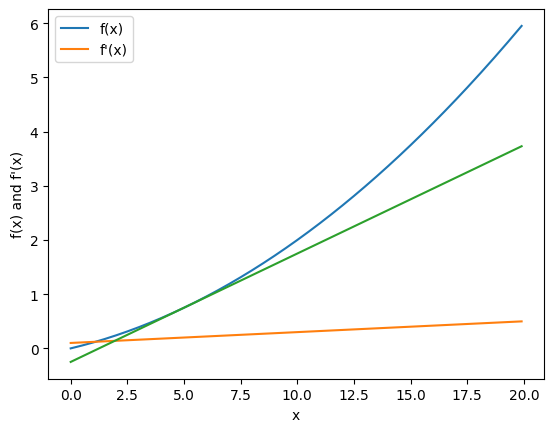

In [1]:
from matplotlib import pyplot as plt
import numpy as np

def mean_square_error(y, t):
    return 0.5 * np.sum((y - t) ** 2)

y = np.array([0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0])
t = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])
mean_square_error(y, t)

# 数值微分
def numerical_diff(f, x):
    h = 1e-4
    return (f(x + h) - f(x - h)) / (2 * h)

def function_1(x):
    return 0.01 * x**2 + 0.1 * x

def target_line(f,x):
    k=numerical_diff(f,x)
    b=f(x)-k*x
    return lambda t: k*t + b


x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)

# 修正数值微分的计算
y1 = np.array([numerical_diff(function_1, xi) for xi in x])
y_diff=target_line(function_1,5)
y2 = y_diff(x)
plt.xlabel("x")
plt.ylabel("f(x) and f'(x)")
plt.plot(x, y, label="f(x)")
plt.plot(x, y1, label="f'(x)")
plt.plot(x, y2)
plt.legend()
plt.show()

梯度是由多个偏导组成的，偏导数的定义如下：
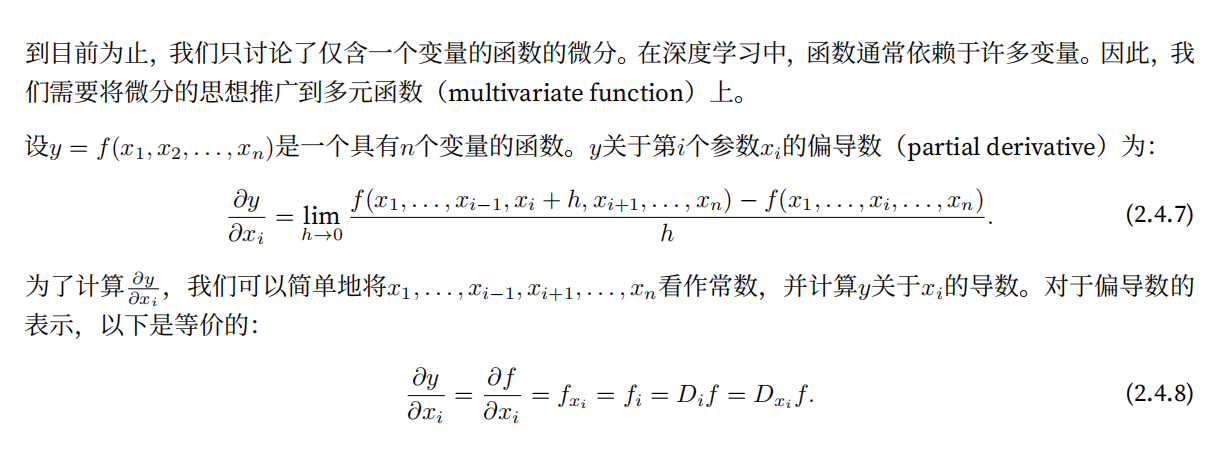

In [ ]:
# 梯度
def numerical_grad(f,x):
    h=1e-4
    grad=np.zeros_like(x)
    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx]=tmp_val+h
        fh1=f(x)
        x[idx]=tmp_val-h #如上图偏导数的定义，这里多元函数来说x一般是向量有多个元素
        fh2=f(x)
        grad[idx]= (fh1-fh2) / (2*h)
        x[idx]=tmp_val #还原值
    return grad

def function_2(x):
    return x[0]**2+x[1]**2


x=np.array([3.0,4.0])
numerical_grad(function_2,x)
y=np.array([1,2])



(array([[3., 4.],
        [3., 4.]]),
 array([[1, 1],
        [2, 2]]))

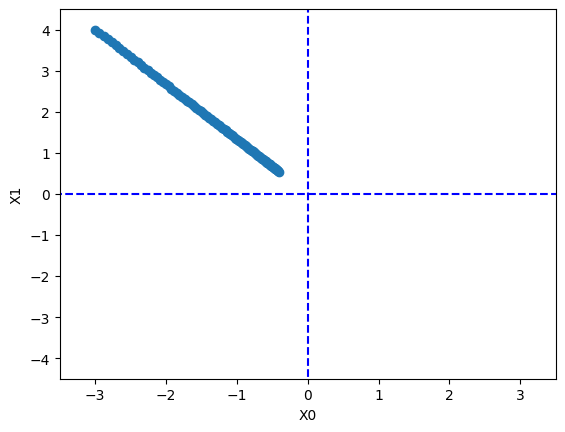

(array([-0.39785867,  0.53047822]),
 array([[-3.        ,  4.        ],
        [-2.94      ,  3.92      ],
        [-2.8812    ,  3.8416    ],
        [-2.823576  ,  3.764768  ],
        [-2.76710448,  3.68947264],
        [-2.71176239,  3.61568319],
        [-2.65752714,  3.54336952],
        [-2.6043766 ,  3.47250213],
        [-2.55228907,  3.40305209],
        [-2.50124329,  3.33499105],
        [-2.45121842,  3.26829123],
        [-2.40219405,  3.2029254 ],
        [-2.35415017,  3.13886689],
        [-2.30706717,  3.07608956],
        [-2.26092582,  3.01456777],
        [-2.21570731,  2.95427641],
        [-2.17139316,  2.89519088],
        [-2.1279653 ,  2.83728706],
        [-2.08540599,  2.78054132],
        [-2.04369787,  2.7249305 ],
        [-2.00282392,  2.67043189],
        [-1.96276744,  2.61702325],
        [-1.92351209,  2.56468278],
        [-1.88504185,  2.51338913],
        [-1.84734101,  2.46312135],
        [-1.81039419,  2.41385892],
        [-1.77418631,  2.365

In [ ]:
def grad_descent(f,init_x,lr=0.01,step_sum=100):
    x = init_x
    x_history=[]
    for i in range(step_sum):
        x_history.append(x.copy())
        grad=numerical_grad(f,x)
        x-=lr*grad
    return x,np.array(x_history)

init_x = np.array([-3.0,4.0])
x,x_history = grad_descent(function_2,init_x,0.01,100)
plt.plot( [-5, 5], [0,0], '--b')
plt.plot( [0,0], [-5, 5], '--b')
plt.plot(x_history[:,0], x_history[:,1], 'o') #使用切片:,1表示第1列

plt.xlim(-3.5, 3.5)
plt.ylim(-4.5, 4.5)
plt.xlabel("X0")
plt.ylabel("X1")
plt.show()
x,x_history

In [98]:
from functions import *
a = np.array([[1,0,0,0,0],
              [0,1,0,0,0],
              [0,0,1,0,0]])

a.argmax(axis=1)
a[0,0]

1

In [15]:
from functions import *
import numpy
def numerical_grad(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x)
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    # 建立多维数组索引
    # 每次还是计算一个点处的偏导
    # 只不过np.nditer 可以自动遍历所有元素的位置
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = tmp_val + h
        fxh1 = f(x) # f(x+h)
        
        x[idx] = tmp_val - h 
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        
        x[idx] = tmp_val # 値を元に戻す
        it.iternext()   
        
    return grad
class TwoLayerNet:
    def __init__(self,input_size,hidden_size,output_size,
                 weight_init_std=0.01):
        # 这里的params是保存神经网络 的字典型变量
        # params['W1']是第1层的权重，params['b1']是第1层的偏置。
        # params['W2']是第2层的权重，params['b2']是第2层的偏置
        self.params={}
        # 随机化权重
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)
    def predict(self,x):
        W1,W2=self.params['W1'],self.params['W2']
        b1,b2=self.params['b1'],self.params['b2']
        a1=np.dot(x,W1)+b1 # 注意这里矩阵乘法顺序写对，写错会报错的
        z1=sigmoid(a1)
        a2=np.dot(z1,W2)+b2
        y=softmax(a2)
        
        return y

    def loss(self,x,t):
        y = self.predict(x)

        return cross_entropy_error(y,t)
    
    def accuracy(self,x,t):
        y=self.predict(x)
        y=np.argmax(y,axis=1)
        t=np.argmax(t,axis=1)

        accuracy=np.sum(y==t)/float(x.shape[0]) #行数
        return accuracy
    def numerical_grad(self,x,t):
        grads = {}
        loss_W = lambda W: self.loss(x,t)
        # 这里使用匿名函数来生成一个以w为变量的函数，这样的话便可以计算其的梯度
        grads['W1'] = numerical_grad(loss_W,self.params['W1'])
        grads['b1'] = numerical_grad(loss_W,self.params['b1'])
        grads['W2'] = numerical_grad(loss_W,self.params['W2'])
        grads['b2'] = numerical_grad(loss_W,self.params['b2'])

        return grads
    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}
        
        batch_num = x.shape[0]
        
        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        
        # backward
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)
        
        dz1 = np.dot(dy, W2.T)
        da1 = sigmoid_grad(a1) * dz1
        grads['W1'] = np.dot(x.T, da1)
        grads['b1'] = np.sum(da1, axis=0)

        return grads
    


In [10]:
net = TwoLayerNet(input_size=784,hidden_size=10,output_size=10)
x = np.random.rand(10,784)
t = np.random.rand(10,10)
y= net.predict(x)
grads = net.numerical_grad(x,t)
grads

{'W1': array([[ 2.27124763e-04, -8.66231094e-04,  5.66054077e-04, ...,
          7.75357800e-05, -2.92932991e-04,  3.55435816e-04],
        [ 1.78597974e-04, -6.82711270e-04,  8.13442205e-04, ...,
          1.92735234e-04, -4.74858362e-04,  6.48092073e-04],
        [ 3.94499313e-04, -4.73032162e-04,  3.33648424e-04, ...,
          1.26573967e-04, -6.97408735e-04,  6.09659427e-04],
        ...,
        [ 2.95073894e-04, -5.63130467e-04,  3.94001149e-04, ...,
          1.31075690e-04, -3.63053756e-04,  1.41536276e-04],
        [ 5.21066204e-04, -1.36421126e-04,  2.54387211e-04, ...,
          2.66033786e-04, -5.21026957e-04,  3.60597381e-04],
        [ 3.25050542e-04, -8.22300248e-04,  4.45247261e-04, ...,
          2.60423372e-05, -6.17372564e-04,  6.68519160e-04]]),
 'b1': array([ 0.00063933, -0.00120432,  0.00082191,  0.00084707, -0.00022161,
        -0.00197928,  0.00057941,  0.00022007, -0.0010195 ,  0.00078351]),
 'W2': array([[ 1.50971120e-04,  5.50573186e-02,  7.81519311e-04,
   

train acc, test acc | 0.10218333333333333, 0.101
train acc, test acc | 0.78445, 0.7891
train acc, test acc | 0.8739666666666667, 0.878
train acc, test acc | 0.8968166666666667, 0.9025
train acc, test acc | 0.9080833333333334, 0.9109
train acc, test acc | 0.9146, 0.9159
train acc, test acc | 0.9191833333333334, 0.9203
train acc, test acc | 0.9229, 0.9258
train acc, test acc | 0.92775, 0.9284
train acc, test acc | 0.9301833333333334, 0.9308
train acc, test acc | 0.9334666666666667, 0.9336
train acc, test acc | 0.9362333333333334, 0.9352
train acc, test acc | 0.93885, 0.9385
train acc, test acc | 0.9404666666666667, 0.9398
train acc, test acc | 0.9426, 0.94
train acc, test acc | 0.9445166666666667, 0.9422
train acc, test acc | 0.9461333333333334, 0.9442
train acc, test acc | 0.9477, 0.9451
train acc, test acc | 0.9492833333333334, 0.9467
train acc, test acc | 0.9509833333333333, 0.948
train acc, test acc | 0.9524833333333333, 0.9484
train acc, test acc | 0.9538, 0.9486
train acc, test acc

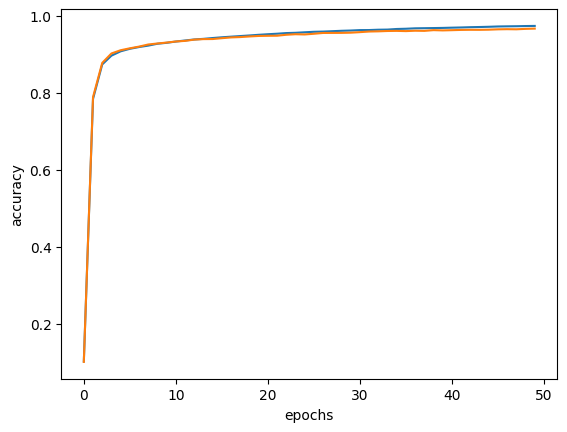

In [21]:
from dataset.mnist import load_mnist
from matplotlib import pyplot as plt
(x_train,t_train),(x_test,t_test)=load_mnist(normalize=True,one_hot_label=True)

train_loss_list=[]

# 超参数
# mini-batch训练
iters_num=30000
train_size=x_train.shape[0]
batch_size=100
learning_rate=0.1
train_acc_list = []
test_acc_list = []
network=TwoLayerNet(input_size=784,hidden_size=50,output_size=10)
iter_per_epoch = max(train_size/batch_size,1)
for i in range(iters_num):
    batch_mask=np.random.choice(train_size,batch_size)
    x_batch=x_train[batch_mask]
    t_batch=t_train[batch_mask]

    grad=network.gradient(x_batch,t_batch)

    for key in ('W1','b1', 'W2','b2'):# 梯度下降法
        network.params[key]-=learning_rate*grad[key]
    loss = network.loss(x_batch,t_batch)
    train_loss_list.append(loss)
    if i%iter_per_epoch==0:
        train_acc=network.accuracy(x_train,t_train)
        test_acc=network.accuracy(x_test,t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
x=np.arange(len(train_acc_list))
plt.plot(x,train_acc_list,label='train acc')
plt.plot(x,test_acc_list,label='test acc')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.show()

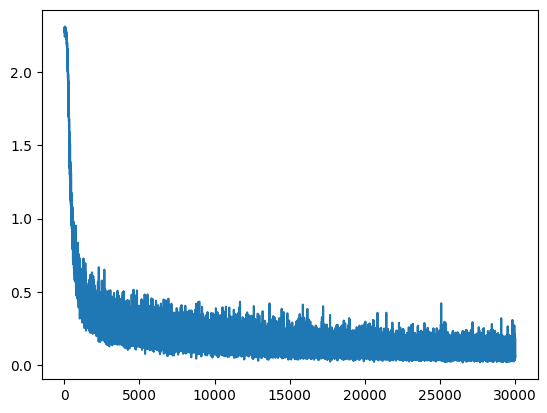

In [22]:
x=np.arange(len(train_loss_list))
plt.plot(x,train_loss_list,label='train acc')

C:\Users\asus\AppData\Local\Temp\ipykernel_16888\3332660109.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


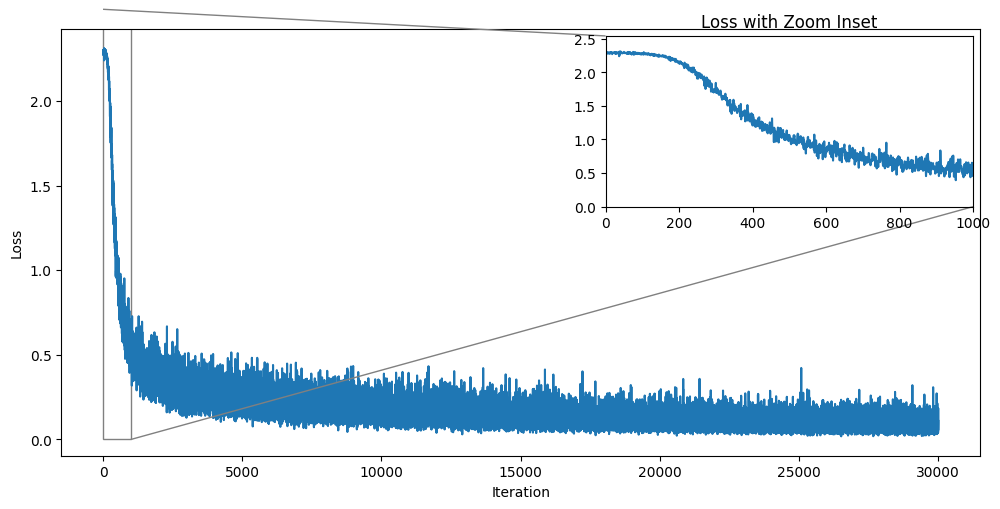

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 假设你已有 train_loss_list（长度为6000）
train_loss_array = np.array(train_loss_list)

# 整体图
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(len(train_loss_array)), train_loss_array, label="Loss")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")

# 插入放大子图
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# 创建插图区域（位置：右上角；大小：宽高占主图的40%）
axins = inset_axes(ax, width="40%", height="40%", loc='upper right')

# 设置放大区域内容（只看前1000轮）
x1, x2 = 0, 1000
axins.plot(np.arange(len(train_loss_array)), train_loss_array)
axins.set_xlim(x1, x2)
axins.set_ylim(0, np.max(train_loss_array[:1000]) * 1.1)  # 自动确定纵轴范围

# 画连接线
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="gray")

plt.title("Loss with Zoom Inset")
plt.tight_layout()
plt.show()
